# Modelo de crecimiento Lógistico Ecuación de Verhulst 

## Motivación

El modelo de crecimiento exponencial:

$$
\frac{dN}{dt} = rN
$$

describe un crecimiento ilimitado, lo cual no es realista en sistemas donde existen restricciones de recursos.



## 2. Formulación del modelo logístico

Para incorporar limitaciones, se introduce un factor de saturación:

$$
\left(1 - \frac{N}{K}\right)
$$

donde:
- $ N(t) $: tamaño de la población
- $  r $: tasa de crecimiento intrínseca
- $ K $: capacidad de carga

La ecuación de Verhulst queda:

$$
\frac{dN}{dt} = rN\left(1 - \frac{N}{K}\right)
$$

---

## 🔧 3. Solución de la ecuación diferencial

### Paso 1: Separación de variables

$$
\frac{dN}{N(1 - N/K)} = r\,dt
$$



### Paso 2: Fracciones parciales

$$
\frac{1}{N(1 - N/K)} = \frac{1}{N} + \frac{1}{K - N}
$$



### Paso 3: Integración

$$
\int \left( \frac{1}{N} + \frac{1}{K - N} \right) dN = \int r\,dt
$$

$$
\ln|N| - \ln|K - N| = rt + C
$$



### Paso 4: Simplificación

$$
\ln\left(\frac{N}{K - N}\right) = rt + C
$$



### Paso 5: Solución explícita

$$
\frac{N}{K - N} = Ae^{rt}
$$

$$
N(t) = \frac{K}{1 + Ae^{-rt}}
$$

donde $ A $ depende de la condición inicial.

Si tomamos $N(0) = N_0 $

Haciendo un poco de álgebra tendremos que:

$$
N = \frac{N_0\cdot K\cdot e^{rt}}{K+N_0( e^{rt}-1)}
$$
---
## 4. Interpretación

La solución es una función sigmoide con tres fases:

1. Crecimiento exponencial inicial $ N \ll K $
2. Desaceleración por competencia  
3. Saturación $ N \to K $

Además:

$$
\lim_{t \to \infty} N(t) = K
$$

---

## 5. Interpretación estructural

La ecuación también puede escribirse como:

$$
\frac{dN}{dt} = rN - \frac{r}{K}N^2
$$

- $rN $: crecimiento
- $ -\frac{r}{K}N^2 $: competencia entre individuos

---

## 6. Limitaciones del modelo

El modelo asume:

- Capacidad de carga constante  
- Interacciones homogéneas  
- Ausencia de retardos  

En datos reales pueden requerirse modelos más complejos como:

- Gompertz  
- Logístico generalizado  
- Modelos con retardo  

---

## 7. Observaciones

El modelo logístico es una extensión natural del crecimiento exponencial que incorpora saturación mediante un término cuadrático, representando competencia entre individuos y limitación de recursos.

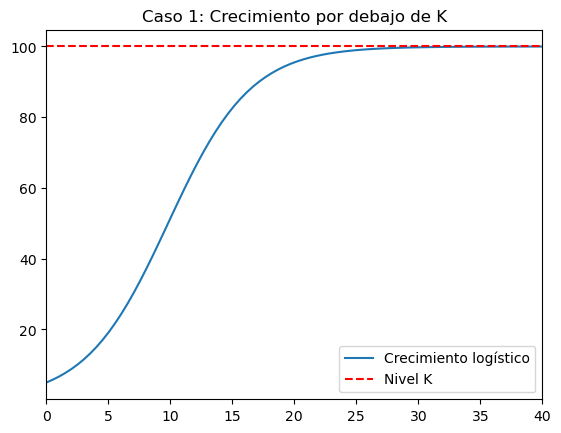

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def logistic(t, K, r, N0):
    return K / (1 + ((K - N0)/N0)*np.exp(-r*t))

t = np.linspace(0, 50, 100)

K = 100
r = 0.3
N0 = 5

N = logistic(t, K, r, N0)

plt.figure()
plt.plot(t, N, label="Crecimiento logístico")
plt.axhline(y=K, linestyle="--", label="Nivel K", color = 'r')
plt.title("Caso 1: Crecimiento por debajo de K")
plt.legend()
plt.xlim(0, 40)
#plt.savefig("crecimiento_logistico_caso1.png")
plt.show()

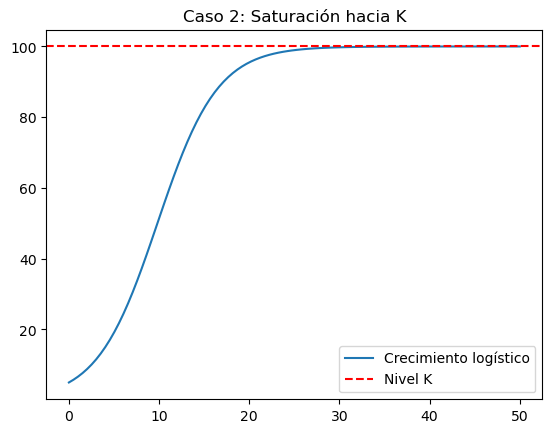

In [ ]:
t = np.linspace(0, 50, 100)

K = 100
r = 0.3
N0 = 5

N = logistic(t, K, r, N0)

plt.figure()
plt.plot(t, N, label="Crecimiento logístico")
plt.axhline(y=K, linestyle="--", label="Nivel K", color = 'r')
plt.title("Caso 2: Saturación hacia K")
plt.legend()
#plt.savefig("crecimiento_logistico_caso2.png")
plt.show()

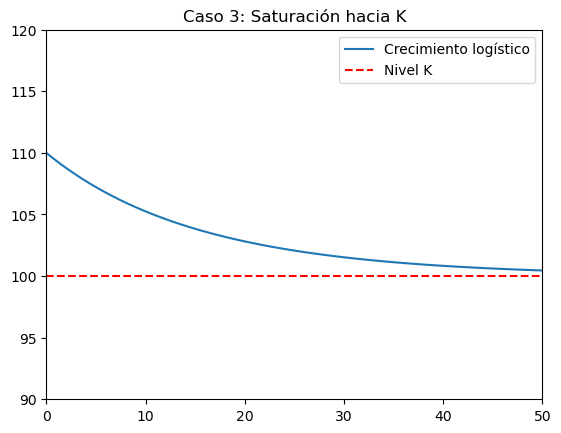

In [ ]:
t = np.linspace(0, 50, 100)
K = 100
r = 0.06
N0 = 110

N = logistic(t, K, r, N0)

plt.figure()
plt.plot(t, N, label="Crecimiento logístico")
plt.axhline(y=K, linestyle="--", label="Nivel K", color = 'r')
plt.title("Caso 3: Saturación hacia K")
plt.legend()
plt.xlim(0, 50)
plt.ylim(90,120)
#plt.savefig("crecimiento_logistico_caso3.png")
plt.show()

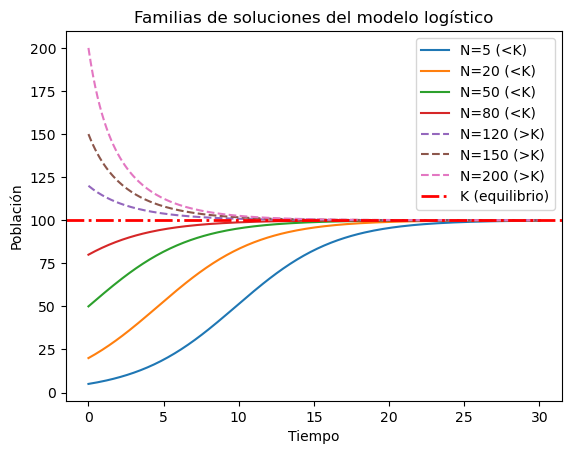

In [ ]:
t = np.linspace(0, 30, 200)

K = 100
r = 0.3

# Condiciones iniciales
below_K = [5, 20, 50, 80]
above_K = [120, 150, 200]

plt.figure()

# Curvas por debajo de K
for N0 in below_K:
    N = logistic(t, K, r, N0)
    plt.plot(t, N, linestyle="solid", label=f"N={N0} (<K)")

# Curvas por encima de K
for N0 in above_K:
    N = logistic(t, K, r, N0)
    plt.plot(t, N, linestyle="dashed", label=f"N={N0} (>K)")

# Nivel K
plt.axhline(y=K, linestyle="-.", linewidth=2, label="K (equilibrio)", color='red')

plt.title("Familias de soluciones del modelo logístico")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.savefig("Images/familias_logistico.png")
plt.show()

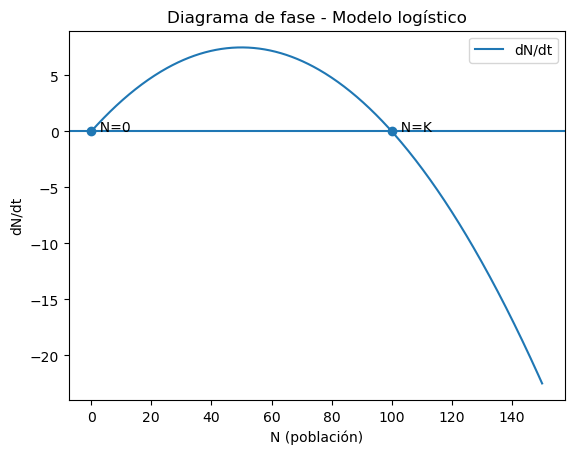

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
r = 0.3
K = 100

# Rango de N
N = np.linspace(0, 150, 500)

# Derivada dN/dt
dNdt = r * N * (1 - N / K)

# Gráfica
plt.figure()
plt.plot(N, dNdt, label="dN/dt")

# Línea horizontal en 0
plt.axhline(0)

# Puntos de equilibrio
plt.scatter([0, K], [0, 0])
plt.text(0, 0, "  N=0")
plt.text(K, 0, "  N=K")

plt.xlabel("N (población)")
plt.ylabel("dN/dt")
plt.title("Diagrama de fase - Modelo logístico")
plt.legend()
plt.show()

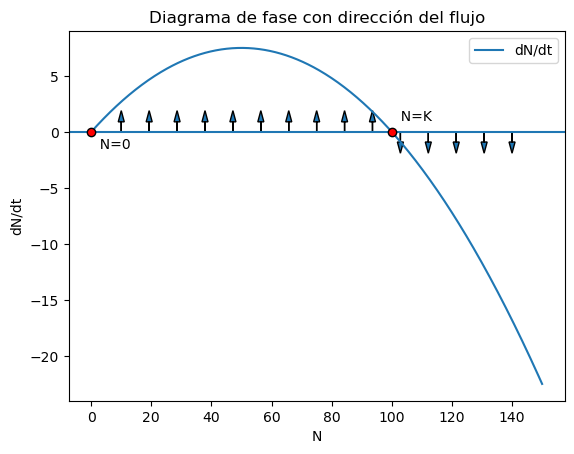

In [ ]:
plt.figure()
# Derivada dN/dt
dNdt = r * N * (1 - N / K)

plt.plot(N, dNdt,label="dN/dt")
plt.scatter([0, K], [0, 0], color = 'red', edgecolors='black', zorder=5)
plt.text(0, -1.5, "  N=0")
plt.text(K, 1, "  N=K")
# Flechas de dirección
for n in np.linspace(10, 140, 15):
    slope = r * n * (1 - n / K)
    plt.arrow(n, 0, 0, 0.9*np.sign(slope), 
              head_width=2, head_length=1)

plt.axhline(0)

plt.xlabel("N")
plt.ylabel("dN/dt")
plt.title("Diagrama de fase con dirección del flujo")
plt.legend()
plt.savefig("Images/diagrama_fase_flujo.png")
plt.show()